# Domain Selection

The selected domain is healthcare drug reviews and drug-disease relationships.

A search engine is useful in this domain because users may want to find drugs associated with specific diseases, compare reported effectiveness, identify common side effects, and retrieve patient experiences.

Potential users include patients, healthcare researchers, pharmacists, and medical data analysts.

The system should support queries such as:
- "drugs for depression with mild side effects"
- "highly effective medication for anxiety"
- "reviews mentioning headache relief"
- "drugs associated with diabetes"

#**Import libraries required for data processing**


In [ ]:
# If running in Colab or a clean environment, uncomment these lines:
# !pip install rank-bm25 sentence-transformers lightgbm transformers torch
# !python -m spacy download en_core_web_sm

In [ ]:
import sys
!{sys.executable} -m pip install rank-bm25

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sqlite3
import os
import warnings
import random
import math

# NLP and Search Libraries
import nltk
from nltk.corpus import stopwords
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi

from datetime import date, timedelta

warnings.filterwarnings('ignore')
%matplotlib inline

#**1. Extraction**

# Dataset Inventory

| Dataset | Source | Format | Records | Key attributes | Text fields | Data quality issues |
|---|---|---|---|---|---|---|
| Drug prescription to disease | Kaggle / public dataset | CSV | 5854 | drug, disease | disease name | duplicates, inconsistent names |
| DrugLib reviews | DrugLib / public dataset | TSV | 3107 | urlDrugName, condition, rating, effectiveness, sideEffects | benefitsReview, sideEffectsReview, commentsReview | missing values, noisy text, inconsistent labels |

In [ ]:
# EXTRAÇÃO DOS DATASETS
# -------------------------------------------------------------------------
# Nesta célula são carregadas as duas fontes originais:
# 1. Dataset estruturado com relações medicamento-doença;
# 2. Dataset DrugLib com reviews textuais e atributos estruturados.
#
# index_col=0 indica que a primeira coluna é tratada como índice antigo e não
# como atributo relevante para o warehouse.
#
# Saídas principais:
# - df_prescriptions: relações medicamento-doença;
# - df_reviews: reviews de utilizadores.
#Loading the two source datasets used
#First column is treated as an old index and discarded with index_col=0.
df_prescriptions = pd.read_csv("Drug prescription to disease.csv", index_col=0)
df_reviews = pd.read_csv("drugLibTrain_raw.tsv", sep="\t", index_col=0)


In [ ]:
print(len(df_prescriptions))
print(len(df_reviews))

14683
3107


## Preview of the first rows of each source dataset


In [ ]:
df_prescriptions.head()

,disease,drug
0,Alkylating Agent Cystitis,sodium bicarbonate
1,Alkylating Agent Cystitis,citric acid / sodium citrate
2,Abdominal Distension,bethanechol
3,Abdominal Distension,pamabrom
4,Abdominal Distension,bethanechol


In [ ]:
df_reviews.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


## Preview of the last rows of each source dataset

In [ ]:
df_prescriptions.tail()

,disease,drug
14678,Zollinger-Ellison Syndrome,ranitidine
14679,Zollinger-Ellison Syndrome,rabeprazole
14680,Zollinger-Ellison Syndrome,cimetidine
14681,Zollinger-Ellison Syndrome,esomeprazole
14682,"Mucormycosis, Invasive",isavuconazonium


In [ ]:
df_reviews.tail()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...
2748,micardis,4,Moderately Effective,Moderate Side Effects,high blood pressure,The drug Micardis did seem to alleviate my hig...,I find when I am taking Micardis that I tend t...,I take Micardis in pill form once daily.


In [ ]:
df_prescriptions.info()
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14683 entries, 0 to 14682
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   disease  14683 non-null  object
 1   drug     14683 non-null  object
dtypes: object(2)
memory usage: 344.1+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   urlDrugName        3107 non-null   object
 1   rating             3107 non-null   int64 
 2   effectiveness      3107 non-null   object
 3   sideEffects        3107 non-null   object
 4   condition          3106 non-null   object
 5   benefitsReview     3089 non-null   object
 6   sideEffectsReview  3032 non-null   object
 7   commentsReview     3095 non-null   object
dtypes: int64(1), object(7)
memory usage: 218.5+ KB


In [ ]:
df_prescriptions.describe()


,disease,drug
count,14683,14683
unique,1508,1615
top,Borderline Personality Disorder,prednisone
freq,350,187


In [ ]:
df_reviews.describe()

,rating
count,3107.000000
mean,7.006115
std,2.937582
min,1.000000
25%,5.000000
50%,8.000000
75%,9.000000
max,10.000000


#**2. Transformation**

In [ ]:
#Standardise entity names before matching records across sources.
#This function creates a comparable canonical form by:
#1) converting text to lowercase;
#2) trimming leading/trailing spaces;
#3) collapsing repeated internal whitespace;
#4) replacing hyphens with spaces to avoid artificial mismatches.
def normalize_name(s):
    if pd.isna(s):
        return None
    s = str(s).lower().strip()
    s = re.sub(r'\s+', ' ', s)
    s = s.replace('-', ' ')
    return s


In [ ]:
# LIMPEZA DO DATASET DE PRESCRIÇÕES
# -------------------------------------------------------------------------
# Passos:
# 1. Criar chaves normalizadas para drug e disease;
# 2. Remover relações incompletas;
# 3. Eliminar pares medicamento-doença duplicados.
#
# A deduplicação evita inflacionar a integração e as análises posteriores.
# -------------------------------------------------------------------------

#Clean the prescription dataset and prepare keys for integration.
#Creation of normalised versions of the drug and disease names, remove rows
#where either side of the relationship is missing, and then keep only unique
#drug-disease pairs so the dimensional model is not inflated by duplicates.
df_prescriptions['drug_norm']    = df_prescriptions['drug'].apply(normalize_name)
df_prescriptions['disease_norm'] = df_prescriptions['disease'].apply(normalize_name)
df_prescriptions.dropna(subset=['drug_norm', 'disease_norm'], inplace=True)
df_prescriptions.drop_duplicates(subset=['drug_norm', 'disease_norm'], inplace=True)
print(f"After dedup - prescriptions: {len(df_prescriptions)} rows")

After dedup - prescriptions: 5854 rows


The integration process links both datasets through normalized drug names.
Drug names are standardized to lowercase, whitespace-normalized, and hyphens are removed to reduce inconsistencies between sources.

In [ ]:
df_prescriptions.head()

,disease,drug,drug_norm,disease_norm
0,Alkylating Agent Cystitis,sodium bicarbonate,sodium bicarbonate,alkylating agent cystitis
1,Alkylating Agent Cystitis,citric acid / sodium citrate,citric acid / sodium citrate,alkylating agent cystitis
2,Abdominal Distension,bethanechol,bethanechol,abdominal distension
3,Abdominal Distension,pamabrom,pamabrom,abdominal distension
6,Abdominal Distension Prior to Abdominal X-ray,vasopressin,vasopressin,abdominal distension prior to abdominal x ray


In [ ]:
# CRIAÇÃO DAS CHAVES DE INTEGRAÇÃO NO DATASET DE REVIEWS
# -------------------------------------------------------------------------
# As mesmas regras de normalização são aplicadas a urlDrugName e condition.
# Assim, drug_norm e condition_norm podem ser comparados com as chaves do
# dataset de prescrições.

#Create standardised join keys in the reviews dataset.
#urlDrugName and condition come from a noisier source, so they are normalised
#using the same rule set applied to the prescription dataset.
df_reviews['drug_norm']      = df_reviews['urlDrugName'].apply(normalize_name)
df_reviews['condition_norm'] = df_reviews['condition'].apply(normalize_name)

In [ ]:
df_reviews.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,drug_norm,condition_norm
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",enalapril,management of congestive heart failure
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",ortho tri cyclen,birth prevention
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,ponstel,menstrual cramps
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,prilosec,acid reflux
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,lyrica,fibromyalgia


In [ ]:


# MAPAS PARA PADRONIZAR RÓTULOS CATEGÓRICOS
# -------------------------------------------------------------------------
# O dataset pode conter categorias escritas com capitalização inconsistente.
# Estes dicionários convertem os valores numa grafia comum.
#
# Não se atribuem ainda pontuações numéricas: primeiro padronizam-se os rótulos.
#Harmonise categorical labels so it can be stored consistently in the
#effectiveness dimension and later translated into ordinal scores.
effectiveness_map = {
    'highly effective': 'Highly Effective',
    'considerably effective': 'Considerably Effective',
    'moderately effective': 'Moderately Effective',
    'marginally effective': 'Marginally Effective',
    'ineffective': 'Ineffective',
}
side_effects_map = {
    'no side effects': 'No Side Effects',
    'mild side effects': 'Mild Side Effects',
    'moderate side effects': 'Moderate Side Effects',
    'severe side effects': 'Severe Side Effects',
    'extremely severe side effects': 'Extremely Severe Side Effects',
}

In [ ]:
# APLICAÇÃO DA PADRONIZAÇÃO CATEGÓRICA
# -------------------------------------------------------------------------
# str.lower() e str.strip() preparam os valores para procurar nos mapas.
# map(...) converte categorias conhecidas.
# fillna(valor_original) preserva rótulos inesperados em vez de os perder.
#Any label not found in the mapping is preserved as-is to avoid accidental
#information loss caused by over-aggressive cleaning.
df_reviews['effectiveness_clean'] = (
    df_reviews['effectiveness'].str.lower().str.strip().map(effectiveness_map)
    .fillna(df_reviews['effectiveness'])
)
df_reviews['side_effects_clean'] = (
    df_reviews['sideEffects'].str.lower().str.strip().map(side_effects_map)
    .fillna(df_reviews['sideEffects'])
)


In [ ]:
# LIMPEZA DOS CAMPOS TEXTUAIS DAS REVIEWS
# -------------------------------------------------------------------------
# clean_text():
# - substitui valores nulos por string vazia;
# - remove espaços redundantes;
# - preserva o conteúdo original da review.
#For narrative columns the original content was kept, but spacing was normalise so
#text is easier to store, search and analyse later.
#Missing values were replaced with empty strings because these fields belong to the review text dimension.
def clean_text(s):
    if pd.isna(s): return ""
    return re.sub(r'\s+', ' ', str(s).strip())

for col in ['benefitsReview', 'sideEffectsReview', 'commentsReview']:
    df_reviews[col] = df_reviews[col].apply(clean_text)

df_reviews.dropna(subset=['drug_norm'], inplace=True)
print(f"After cleaning - reviews: {len(df_reviews)} rows")

After cleaning - reviews: 3107 rows


The integration of prescription and drug review datasets successfully created a unified healthcare data warehouse.

The ETL process improved data quality through cleaning, normalization, and deduplication, allowing information from different sources to be analyzed together.

#**3. Dimension tables**

In [ ]:

# CONSTRUÇÃO DA DIMENSÃO dim_drug
# -------------------------------------------------------------------------
# Uma dimensão reúne atributos descritivos sobre uma entidade.
#
# Nesta dimensão:
# - drug_id: surrogate key criada pelo warehouse;
# - drug_name: nome normalizado usado como business key;
# - drug_name_original: versão legível mantida para apresentação.
#
# Os medicamentos são combinados a partir das duas fontes e deduplicados.

#Build the drug dimension by combining drug references from both sources.
#The normalised name became the business key used for matching, while one
#original version of the name is retained for traceability/readability.
all_drugs = pd.concat([
    df_prescriptions[['drug_norm', 'drug']].rename(columns={'drug': 'drug_name_original'}),
    df_reviews[['drug_norm', 'urlDrugName']].rename(columns={'urlDrugName': 'drug_name_original'}),
])
all_drugs = all_drugs.drop_duplicates(subset='drug_norm')
all_drugs = all_drugs[all_drugs['drug_norm'].notna()].reset_index(drop=True)
all_drugs.insert(0, 'drug_id', range(1, len(all_drugs) + 1))
all_drugs.rename(columns={'drug_norm': 'drug_name'}, inplace=True)
print(f"DIM Drug: {len(all_drugs)} records")

DIM Drug: 2029 records


In [ ]:
all_drugs.head()


,drug_id,drug_name,drug_name_original
0,1,sodium bicarbonate,sodium bicarbonate
1,2,citric acid / sodium citrate,citric acid / sodium citrate
2,3,bethanechol,bethanechol
3,4,pamabrom,pamabrom
4,5,vasopressin,vasopressin


In [ ]:
# CONSTRUÇÃO DA DIMENSÃO dim_disease
# -------------------------------------------------------------------------
# Combina doenças do dataset de prescrições com conditions das reviews.
# O objetivo é criar uma dimensão conformada partilhada pelas duas fontes.
# -------------------------------------------------------------------------
#Build the disease dimension using disease labels from both datasets.
#Review conditions are aligned to the same structure as prescription diseases
#so that both sources can feed one conformed dimension.
all_diseases = pd.concat([
    df_prescriptions[['disease_norm', 'disease']].rename(columns={'disease': 'disease_name_original'}),
    df_reviews[['condition_norm', 'condition']].rename(
        columns={'condition_norm': 'disease_norm', 'condition': 'disease_name_original'}
    ),
])
all_diseases = all_diseases.drop_duplicates(subset='disease_norm')
all_diseases = all_diseases[all_diseases['disease_norm'].notna()].reset_index(drop=True)
all_diseases.insert(0, 'disease_id', range(1, len(all_diseases) + 1))
all_diseases.rename(columns={'disease_norm': 'disease_name'}, inplace=True)
print(f"DIM Disease: {len(all_diseases)} records")

DIM Disease: 2811 records


In [ ]:
all_diseases.head()

,disease_id,disease_name,disease_name_original
0,1,alkylating agent cystitis,Alkylating Agent Cystitis
1,2,abdominal distension,Abdominal Distension
2,3,abdominal distension prior to abdominal x ray,Abdominal Distension Prior to Abdominal X-ray
3,4,abdominal radiological procedure,Abdominal Radiological Procedure
4,5,abnormal uterine bleeding,Abnormal Uterine Bleeding


In [ ]:
# -------------------------------------------------------------------------
# CONSTRUÇÃO DA DIMENSÃO dim_effectiveness
# -------------------------------------------------------------------------
# As categorias qualitativas são convertidas em pontuações ordinais:
# - maior effectiveness_score = maior eficácia reportada;
# - maior side_effects_score = maior severidade dos efeitos secundários.
#
# A dimensão guarda combinações distintas de eficácia e efeitos secundários.
# -------------------------------------------------------------------------

#Define ordinal scores for qualitative review outcomes.
#These numeric values allow simple aggregation and comparison in analytics,
#while the descriptive labels remain available for interpretation.
effectiveness_score_map = {
    'Ineffective':              1,
    'Marginally Effective':     2,
    'Moderately Effective':     3,
    'Considerably Effective':   4,
    'Highly Effective':         5,
}
side_effects_score_map = {
    'No Side Effects':              1,
    'Mild Side Effects':            2,
    'Moderate Side Effects':        3,
    'Severe Side Effects':          4,
    'Extremely Severe Side Effects':5,
}

#Create all distinct label combinations observed in the cleaned reviews.
#This becomes a compact dimension that standardises user-reported outcomes.
eff_combinations = (
    df_reviews[['effectiveness_clean', 'side_effects_clean']]
    .drop_duplicates()
    .reset_index(drop=True)
)
eff_combinations.insert(0, 'effectiveness_id', range(1, len(eff_combinations) + 1))
eff_combinations.rename(columns={
    'effectiveness_clean': 'effectiveness_label',
    'side_effects_clean':  'side_effects_label',
}, inplace=True)



In [ ]:
# ADIÇÃO DAS PONTUAÇÕES À dim_effectiveness
# -------------------------------------------------------------------------
# map(...) procura a pontuação numérica correspondente a cada rótulo limpo.

#Attach the numeric scores to each effectiveness/side-effects combination.
eff_combinations['effectiveness_score'] = (
    eff_combinations['effectiveness_label'].map(effectiveness_score_map)
)
eff_combinations['side_effects_score'] = (
    eff_combinations['side_effects_label'].map(side_effects_score_map)
)
print(f"DIM Effectiveness: {len(eff_combinations)} records (with numeric scores)")

DIM Effectiveness: 25 records (with numeric scores)


#**4. Synthetic date generation**

The original review dataset does not include real review dates. Therefore, synthetic dates were generated only to demonstrate the construction of a time dimension in the data warehouse.

These dates should not be interpreted as real temporal information and are not used to draw medical, clinical or temporal conclusions.

In [ ]:

# -------------------------------------------------------------------------
# GERAÇÃO DE DATAS SINTÉTICAS
# -------------------------------------------------------------------------
# O dataset original não contém datas de review.
# Estas datas artificiais existem apenas para demonstrar uma dimensão temporal.
#
# IMPORTANTE PARA A APRESENTAÇÃO:
# Não podem ser interpretadas como datas reais nem usadas para tirar conclusões
# temporais ou clínicas.
#
# Esta implementação cria padrões artificiais:
# - condições crónicas tendem para anos anteriores;
# - ratings elevados tendem para anos mais recentes;
# - janeiro e fevereiro têm ligeiramente mais peso.
#
# Se a professora pedir uma simplificação, pode-se substituir esta lógica por
# uma distribuição uniforme entre START_DATE e END_DATE.
# -------------------------------------------------------------------------

# Logic:
#   - Base range: 2008-01-01 to 2023-12-31
#   - Chronic condition drugs (diabetes, depression, hypertension, etc.)
#     skew toward earlier years (2008-2015) — established, reviewed longer
#   - High-rated drugs (rating >= 8) skew toward recent years (2016-2023)
#   - Slight seasonal clustering: Jan/Feb get +20% probability weight
#     (new year health resolutions)

CHRONIC_KEYWORDS = {
    'diabetes','depression','anxiety','hypertension','blood pressure',
    'cholesterol','arthritis','asthma','epilepsy','thyroid',
    'bipolar','schizophrenia','heart failure','parkinson',
}

START_DATE = date(2008, 1, 1)
END_DATE   = date(2023, 12, 31)
TOTAL_DAYS = (END_DATE - START_DATE).days

def pick_year_weights(condition_norm, rating):
    """Return (start_offset_days, range_days) based on condition and rating."""
    is_chronic = any(kw in str(condition_norm) for kw in CHRONIC_KEYWORDS)
    if is_chronic:
        # Earlier skew: 2008-2016
        return 0, 365 * 8
    elif rating >= 8:
        # Recent skew: 2015-2023
        return 365 * 7, 365 * 8
    else:
        # Uniform across full range
        return 0, TOTAL_DAYS

def pick_month_weighted():
    """Jan and Feb have slightly higher weight."""
    weights = [1.2, 1.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.1]
    months  = list(range(1, 13))
    return random.choices(months, weights=weights)[0]

def generate_review_date(condition_norm, rating):
    offset_start, offset_range = pick_year_weights(condition_norm, rating)
    day_offset = offset_start + random.randint(0, offset_range)
    base = START_DATE + timedelta(days=day_offset)
    # Override month with weighted month, keep year and pick valid day
    month = pick_month_weighted()
    year  = base.year
    # Clamp to valid date within year/month
    try:
        d = date(year, month, random.randint(1, 28))
    except ValueError:
        d = date(year, month, 1)
    # Make sure within bounds
    if d > END_DATE: d = END_DATE
    if d < START_DATE: d = START_DATE
    return d

## Review Text Dimension


In [ ]:
# -------------------------------------------------------------------------
# CONSTRUÇÃO DA DIMENSÃO dim_review_text
# -------------------------------------------------------------------------
# Cada review recebe review_id, uma surrogate key.
# Também é gerada uma review_date sintética para demonstrar o eixo temporal.
#
# A dimensão guarda os três campos narrativos:
# - benefits_review;
# - side_effects_review;
# - comments_review.
#
# review_date é mantida por conveniência do processo ETL.
# -------------------------------------------------------------------------

# Build the review text dimension.
# Each review receives a surrogate key (review_id) and one synthetic date that
# will later connect the textual review content to the time dimension.

# Build the review text dimension.
# Each review receives a surrogate key (review_id) and one synthetic date that
# will later connect the textual review content to the time dimension.
df_reviews = df_reviews.reset_index(drop=True)
df_reviews['review_id'] = range(1, len(df_reviews) + 1)

review_dates = []
for _, row in df_reviews.iterrows():
    d = generate_review_date(row.get('condition_norm', ''), row['rating'])
    review_dates.append(d)

df_reviews['review_date'] = review_dates

# Keep only the attributes that describe the review text itself.
df_reviews_text = df_reviews[[
    'review_id', 'benefitsReview', 'sideEffectsReview', 'commentsReview', 'review_date'
]].copy()

# Rename columns to follow a cleaner warehouse naming convention.
df_reviews_text.rename(columns={
    'benefitsReview':    'benefits_review',
    'sideEffectsReview': 'side_effects_review',
    'commentsReview':    'comments_review',
}, inplace=True)
print(f"DIM Review Text: {len(df_reviews_text)} records (with synthetic review_date)")
print(f"  Date range: {df_reviews_text['review_date'].min()} → {df_reviews_text['review_date'].max()}")

DIM Review Text: 3107 records (with synthetic review_date)
  Date range: 2008-01-01 → 2023-12-19


In [ ]:
df_reviews.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,drug_norm,condition_norm,effectiveness_clean,side_effects_clean,review_id,review_date
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",enalapril,management of congestive heart failure,Highly Effective,Mild Side Effects,1,2011-05-03
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",ortho tri cyclen,birth prevention,Highly Effective,Severe Side Effects,2,2013-06-07
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,ponstel,menstrual cramps,Highly Effective,No Side Effects,3,2018-05-18
3,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,prilosec,acid reflux,Marginally Effective,Mild Side Effects,4,2018-12-14
4,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not ...,See above,lyrica,fibromyalgia,Marginally Effective,Severe Side Effects,5,2012-11-19


## Time Dimension

In [ ]:
# -------------------------------------------------------------------------
# CONSTRUÇÃO DA DIMENSÃO dim_time
# -------------------------------------------------------------------------
# A dimensão temporal é criada apenas com as datas sintéticas efetivamente
# presentes nas reviews, evitando linhas de calendário desnecessárias.
#
# Para cada data são derivados atributos úteis para análise:
# ano, mês, trimestre, estação, dia da semana e fim de semana.
#
# date_to_time_id permite associar cada review à sua linha em dim_time.
# -------------------------------------------------------------------------


# Build the time dimension from the distinct review dates that actually appear
# in the review text dimension. This avoids storing unnecessary calendar rows.
unique_dates = sorted(df_reviews_text['review_date'].unique())

def get_season(month):
    if month in (12, 1, 2):  return 'Winter'
    if month in (3, 4, 5):   return 'Spring'
    if month in (6, 7, 8):   return 'Summer'
    return 'Autumn'

time_rows = []
for d in unique_dates:
    time_rows.append({
        'date':      d,
        'year':      d.year,
        'month':     d.month,
        'month_name':d.strftime('%B'),
        'quarter':   (d.month - 1) // 3 + 1,
        'season':    get_season(d.month),
        'day_of_week': d.strftime('%A'),
        'is_weekend':  d.weekday() >= 5,
    })

# Add the surrogate key after the dimension content is finalised.
dim_time = pd.DataFrame(time_rows).reset_index(drop=True)
dim_time.insert(0, 'time_id', range(1, len(dim_time) + 1))
print(f"DIM Time: {len(dim_time)} records ({dim_time['year'].min()}–{dim_time['year'].max()})")

# Create a lookup so each review can be linked to the correct time_id.
date_to_time_id = dict(zip(dim_time['date'], dim_time['time_id']))
df_reviews_text['time_id'] = df_reviews_text['review_date'].map(date_to_time_id)

DIM Time: 2304 records (2008–2023)


In [ ]:
dim_time.head()
# PRÉ-VISUALIZAÇÃO DA DIMENSÃO TEMPORAL


,time_id,date,year,month,month_name,quarter,season,day_of_week,is_weekend
0,1,2008-01-01,2008,1,January,1,Winter,Tuesday,False
1,2,2008-01-05,2008,1,January,1,Winter,Saturday,True
2,3,2008-01-06,2008,1,January,1,Winter,Sunday,True
3,4,2008-01-09,2008,1,January,1,Winter,Wednesday,False
4,5,2008-01-12,2008,1,January,1,Winter,Saturday,True


# **4. Fact table**

# Fact Table Grain

The grain of the fact table is one drug review event.  
Each row represents one review written for a drug, associated when possible with a disease/condition, effectiveness category, side effect category, and review date.

Measures:
- rating: numerical score given in the review.
- review_count: implicit measure, each fact row counts as one review.
- pair_match: Boolean indicator showing whether the drug-condition pair exists in the prescription dataset.

In [ ]:
# CONSTRUÇÃO DA FACT TABLE fact_drug_review
# -------------------------------------------------------------------------
# Grain: uma linha representa uma review individual de um medicamento.
#
# A fact table contém foreign keys para as dimensões e duas medidas principais:
# - rating: avaliação numérica dada pelo utilizador;
# - pair_match: True quando o par medicamento-doença da review também existe
#   no dataset estruturado de prescrições.
#
# Lookups:
# - drug_lookup liga drug_name normalizado a drug_id;
# - disease_lookup liga disease_name normalizado a disease_id;
# - eff_lookup liga a combinação eficácia/efeitos a effectiveness_id;
# - review_time_lookup liga review_id a time_id.
#
# valid_pairs é um set para tornar eficiente a verificação de pair_match.

print("\n=== BUILDING FACT TABLE ===")

# Prepare fast lookups from business keys to surrogate keys.
drug_lookup    = dict(zip(all_drugs['drug_name'],       all_drugs['drug_id']))
disease_lookup = dict(zip(all_diseases['disease_name'], all_diseases['disease_id']))
eff_lookup     = {
    (row['effectiveness_label'], row['side_effects_label']): row['effectiveness_id']
    for _, row in eff_combinations.iterrows()
}
review_time_lookup = dict(zip(df_reviews_text['review_id'], df_reviews_text['time_id']))

# Create fast lookup set for valid drug-disease pairs
valid_pairs = set(
    zip(
        df_prescriptions['drug_norm'],
        df_prescriptions['disease_norm']
    )
)

fact_rows = []

for _, row in df_reviews.iterrows():

    drug_id = drug_lookup.get(row['drug_norm'])

    disease_name = row['condition_norm'] if pd.notna(row.get('condition_norm')) else None
    disease_id = disease_lookup.get(disease_name) if disease_name else None

    eff_key = (
        row['effectiveness_clean'],
        row['side_effects_clean']
    )

    eff_id = eff_lookup.get(eff_key)

    time_id = review_time_lookup.get(row['review_id'])

    # Check if the drug-disease pair exists
    pair_match = (
        (row['drug_norm'], disease_name)
        in valid_pairs
    )

    fact_rows.append({
        'drug_id': drug_id,
        'disease_id': disease_id,
        'effectiveness_id': eff_id,
        'review_id': row['review_id'],
        'time_id': time_id,
        'rating': row['rating'],
        'pair_match': pair_match
    })


fact_table = pd.DataFrame(fact_rows)
fact_table.insert(0, 'fact_id', range(1, len(fact_table) + 1))

print(f"FACT Drug Review: {len(fact_table)} records")
print(f"  - disease_id resolved:   {fact_table['disease_id'].notna().sum()}")
print(f"  - time_id resolved:      {fact_table['time_id'].notna().sum()}")
print(f"  - rating range:          {fact_table['rating'].min()} – {fact_table['rating'].max()}")

fact_table.head()


=== BUILDING FACT TABLE ===
FACT Drug Review: 3107 records
  - disease_id resolved:   3106
  - time_id resolved:      3107
  - rating range:          1 – 10


,fact_id,drug_id,disease_id,effectiveness_id,review_id,time_id,rating,pair_match
0,1,204,1509.0,1,1,450,4,False
1,2,1616,1510.0,2,2,735,1,False
2,3,1617,1511.0,3,3,1506,10,False
3,4,1618,1512.0,4,4,1596,3,False
4,5,1619,669.0,5,5,652,2,False


In [ ]:
fact_table
# VISUALIZAÇÃO COMPLETA DA FACT TABLE


,fact_id,drug_id,disease_id,effectiveness_id,review_id,time_id,rating,pair_match
0,1,204,1509.0,1,1,450,4,False
1,2,1616,1510.0,2,2,735,1,False
2,3,1617,1511.0,3,3,1506,10,False
3,4,1618,1512.0,4,4,1596,3,False
4,5,1619,669.0,5,5,652,2,False
...,...,...,...,...,...,...,...,...
3102,3103,1621,1526.0,1,3103,1422,10,False
3103,3104,1700,515.0,8,3104,71,1,False
3104,3105,1778,2811.0,23,3105,485,2,False
3105,3106,2029,613.0,11,3106,591,8,False


# **5. Loading**

In [ ]:
# EXPORTAÇÃO DO WAREHOUSE PARA CSV
# -------------------------------------------------------------------------
# Cada tabela é guardada separadamente para inspeção independente do SQLite.
# try/except evita que uma falha num ficheiro interrompa silenciosamente o ETL.
# -------------------------------------------------------------------------
# Export each warehouse table to CSV so the dimensional model is available
# outside the notebook and can be inspected independently of SQLite.
OUTPUT_DIR = "warehouse_output"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

tables_to_save = {
    "dim_drug.csv":          all_drugs,
    "dim_disease.csv":       all_diseases,
    "dim_effectiveness.csv": eff_combinations,
    "dim_review_text.csv":   df_reviews_text,
    "dim_time.csv":          dim_time,
    "fact_drug_review.csv":  fact_table
}

for filename, df in tables_to_save.items():
    try:
        path = os.path.join(OUTPUT_DIR, filename)
        df.to_csv(path, index=False, encoding='utf-8')
        print(f"Saved CSV: {filename}")
    except Exception as e:
        print(f"Error saving {filename}: {e}")

Saved CSV: dim_drug.csv
Saved CSV: dim_disease.csv
Saved CSV: dim_effectiveness.csv
Saved CSV: dim_review_text.csv
Saved CSV: dim_time.csv
Saved CSV: fact_drug_review.csv


In [ ]:

# CARREGAMENTO FÍSICO DO DATA WAREHOUSE EM SQLITE
# -------------------------------------------------------------------------
# Fluxo:
# 1. Abrir ligação SQLite;
# 2. Ativar foreign keys;
# 3. Remover tabelas antigas para permitir rerun limpo;
# 4. Criar dimensões e fact table;
# 5. Inserir os DataFrames;
# 6. Criar índices para acelerar joins frequentes;
# 7. Fazer commit e fechar a ligação.
#
# O SQLite materializa o modelo dimensional num sistema de base de dados.
# -------------------------------------------------------------------------





# Load the dimensional model into SQLite to create a persistent warehouse.
# The schema is rebuilt from scratch so repeated notebook executions always
# produce a clean and consistent final database.
DB_NAME = "drug_warehouse.db"
try:
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    conn.execute("PRAGMA foreign_keys = ON;")

    print(f"\nConnected to database: {DB_NAME}")

    # Create dimension and fact tables with primary/foreign key constraints.
    print("Implementing physical schema (Keys, Constraints, Indexes)...")
    cursor.executescript("""
    DROP TABLE IF EXISTS fact_drug_review;
    DROP TABLE IF EXISTS dim_drug;
    DROP TABLE IF EXISTS dim_disease;
    DROP TABLE IF EXISTS dim_effectiveness;
    DROP TABLE IF EXISTS dim_review_text;
    DROP TABLE IF EXISTS dim_time;

    CREATE TABLE dim_drug (
        drug_id INTEGER PRIMARY KEY,
        drug_name TEXT NOT NULL,
        drug_name_original TEXT
    );

    CREATE TABLE dim_disease (
        disease_id INTEGER PRIMARY KEY,
        disease_name TEXT NOT NULL,
        disease_name_original TEXT
    );

    CREATE TABLE dim_effectiveness (
        effectiveness_id INTEGER PRIMARY KEY,
        effectiveness_label TEXT,
        side_effects_label TEXT,
        effectiveness_score INTEGER,
        side_effects_score INTEGER
    );

    CREATE TABLE dim_review_text (
        review_id INTEGER PRIMARY KEY,
        benefits_review TEXT,
        side_effects_review TEXT,
        comments_review TEXT,
        review_date DATE,
        time_id INTEGER
    );

    CREATE TABLE dim_time (
        time_id INTEGER PRIMARY KEY,
        date DATE,
        year INTEGER,
        month INTEGER,
        month_name TEXT,
        quarter INTEGER,
        season TEXT,
        day_of_week TEXT,
        is_weekend BOOLEAN
    );

    CREATE TABLE fact_drug_review (
        fact_id INTEGER PRIMARY KEY,
        drug_id INTEGER,
        disease_id INTEGER,
        effectiveness_id INTEGER,
        review_id INTEGER,
        time_id INTEGER,
        rating INTEGER,
        pair_match BOOLEAN,
        FOREIGN KEY (drug_id) REFERENCES dim_drug(drug_id),
        FOREIGN KEY (disease_id) REFERENCES dim_disease(disease_id),
        FOREIGN KEY (effectiveness_id) REFERENCES dim_effectiveness(effectiveness_id),
        FOREIGN KEY (review_id) REFERENCES dim_review_text(review_id),
        FOREIGN KEY (time_id) REFERENCES dim_time(time_id)
    );
    """)

    # Populate SQLite tables directly from the pandas DataFrames already built
    # during the transformation phase.
    db_mapping = {
        "dim_drug":          all_drugs,
        "dim_disease":       all_diseases,
        "dim_effectiveness": eff_combinations,
        "dim_review_text":   df_reviews_text,
        "dim_time":          dim_time,
        "fact_drug_review":  fact_table
    }

    for table_name, df in db_mapping.items():
        df.to_sql(table_name, conn, if_exists='append', index=False)
        print(f"Loaded {len(df)} rows into {table_name}")

    # Add indexes on frequently joined fact-table foreign keys to improve query performance.
    cursor.execute("CREATE INDEX idx_fact_drug ON fact_drug_review(drug_id);")
    cursor.execute("CREATE INDEX idx_fact_disease ON fact_drug_review(disease_id);")

    conn.commit()
    conn.close()
    print("\n=== ETL PIPELINE COMPLETE: WAREHOUSE POPULATED ===")

except Exception as e:
    print(f"FATAL ERROR during database load: {e}")


Connected to database: drug_warehouse.db
Implementing physical schema (Keys, Constraints, Indexes)...
Loaded 2029 rows into dim_drug
Loaded 2811 rows into dim_disease
Loaded 25 rows into dim_effectiveness
Loaded 3107 rows into dim_review_text
Loaded 2304 rows into dim_time
Loaded 3107 rows into fact_drug_review

=== ETL PIPELINE COMPLETE: WAREHOUSE POPULATED ===


###  Searchable Documents Extraction

In [ ]:
# PREPARAÇÃO DOS RECURSOS DE NLP
# -------------------------------------------------------------------------
# NLTK fornece stopwords inglesas.
# spaCy carrega o modelo de língua inglesa para lematização.
#
# O fallback nlp=None permite continuar com processamento básico se o modelo
# spaCy não estiver disponível.
# -------------------------------------------------------------------------
# NLP Resource Setup

try:
    nltk.download("stopwords", quiet=True)

    # Load spaCy model
    # If this fails, run: python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

except Exception as e:
    print(f"Warning: NLP resources could not be fully loaded. {e}")
    nlp = None

stop_en = set(stopwords.words("english"))

## Preprocessing Functions

In [ ]:
# EXTRAÇÃO DOS DOCUMENTOS PESQUISÁVEIS E PRÉ-PROCESSAMENTO
# -------------------------------------------------------------------------
# lemmatize_text():
# - converte para lowercase;
# - transforma palavras na sua forma base através de lematização;
# - remove stopwords;
# - mantém apenas tokens alfabéticos.
#
# search_docs é criado através de merges entre a fact table e as dimensões.
# Cada documento concatenado reúne informação estruturada e texto livre.
#
# Todos os campos são concatenados uma vez, por isso têm peso implícito igual.


def lemmatize_text(text):
    if nlp is None:
        # Handle case where NLP resources might not have loaded successfully
        return str(text).lower() # Fallback to just lowercasing
    text = str(text).lower()
    doc = nlp(text)
    lemmas = [
        token.lemma_ for token in doc
        if token.text.lower() not in stop_en and token.is_alpha
    ]
    return " ".join(lemmas)

search_docs = (
    fact_table
    .merge(all_drugs, on='drug_id', how='left')
    .merge(all_diseases, on='disease_id', how='left')
    .merge(eff_combinations, on='effectiveness_id', how='left')
    .merge(df_reviews_text, on='review_id', how='left')
)

# Create integrated searchable text
search_docs['document_text'] = (
    search_docs['drug_name_original'].fillna('') + ' ' +
    search_docs['disease_name_original'].fillna('') + ' ' +
    search_docs['effectiveness_label'].fillna('') + ' ' +
    search_docs['side_effects_label'].fillna('') + ' ' +
    search_docs['benefits_review'].fillna('') + ' ' +
    search_docs['side_effects_review'].fillna('') + ' ' +
    search_docs['comments_review'].fillna('')
)

# Preprocess text
search_docs['searchable_text'] = (
    search_docs['document_text']
    .apply(lemmatize_text)
)

print(search_docs[['review_id', 'searchable_text']].head())

   review_id                                    searchable_text
0          1  enalapril management congestive heart failure ...
1          2  ortho tri cyclen birth prevention highly effec...
2          3  ponstel menstrual cramp highly effective side ...
3          4  prilosec acid reflux marginally effective mild...
4          5  lyrica fibromyalgia marginally effective sever...


In [ ]:
# MODELO 1 — TF-IDF + COSINE SIMILARITY
# -------------------------------------------------------------------------
# TF-IDF atribui mais peso a termos importantes num documento e menos peso a
# palavras muito frequentes em toda a coleção.
#
# search_tfidf():
# 1. Pré-processa a query;
# 2. Converte-a num vetor TF-IDF;
# 3. Calcula cosine similarity com todos os documentos;
# 4. Ordena por score;
# 5. Devolve os top_k resultados.
# 5. TF-IDF Vectorization & Search Engine Setup
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(search_docs['searchable_text'])

def search_tfidf(query, top_k=5):
    q = lemmatize_text(query)
    q_vec = vectorizer.transform([q])
    sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
    ranking = sims.argsort()[::-1][:top_k]

    results = search_docs.iloc[ranking][[
        'review_id',
        'drug_name_original',
        'disease_name_original',
        'effectiveness_label',
        'side_effects_label',
        'rating'
    ]].copy()

    results['score'] = sims[ranking]

    return results

print("\nExample Search Result for 'headache relief':")
print(search_tfidf("headache relief", top_k=2))


Example Search Result for 'headache relief':
      review_id drug_name_original disease_name_original  \
1636       1637              zomig      cluster headache   
100         101            tylenol                  Pain   

         effectiveness_label     side_effects_label  rating     score  
1636  Considerably Effective  Moderate Side Effects       8  0.534685  
100     Moderately Effective      Mild Side Effects       3  0.421231  


## BM25 Retrieval Model

In [ ]:
# BM25 é um modelo probabilístico lexical.
# Considera:
# - frequência do termo no documento;
# - raridade do termo na coleção;
# - normalização do comprimento do documento.
#
# Ao contrário do TF-IDF básico, BM25 penaliza melhor textos excessivamente
# longos e costuma funcionar bem em motores de pesquisa tradicionais.
# -------------------------------------------------------------------

# Corpus tokenization: convert the normalized and lemmatized texts
# into lists of tokens so that BM25 can analyze them.
tokenized_corpus = [
    doc.split()
    for doc in search_docs['searchable_text']
]

# Train BM25
bm25 = BM25Okapi(tokenized_corpus)

def search_bm25(query, top_k=5):
    """
    BM25 search function.
    BM25 ranks documents using term frequency, inverse document frequency,
    and document length normalization.
    """

    processed_query = lemmatize_text(query)
    tokenized_query = processed_query.split()

    scores = bm25.get_scores(tokenized_query)

    ranking = np.argsort(scores)[::-1][:top_k]

    results = search_docs.iloc[ranking][[
        'review_id',
        'drug_name_original',
        'disease_name_original',
        'effectiveness_label',
        'side_effects_label',
        'rating'
    ]].copy()

    results['score'] = scores[ranking]

    return results

## Comparison of Models

In [ ]:
# Executa a mesma query nos dois modelos para observar diferenças de ranking.

query = "depression mild side effects"

print("TF-IDF RESULTS")
display(search_tfidf(query, top_k=5))

print("BM25 RESULTS")
display(search_bm25(query, top_k=5))

TF-IDF RESULTS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
258,259,zoloft,Depression,Considerably Effective,No Side Effects,9,0.422748
12,13,sarafem,Depression,Considerably Effective,Mild Side Effects,8,0.396994
3031,3032,prozac,Depression,Moderately Effective,Mild Side Effects,8,0.394239
2263,2264,effexor,Depression,Considerably Effective,Mild Side Effects,8,0.388681
2155,2156,zoloft,Depression,Highly Effective,Mild Side Effects,9,0.372614


BM25 RESULTS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
12,13,sarafem,Depression,Considerably Effective,Mild Side Effects,8,10.089004
2578,2579,wellbutrin-xl,depression/dysthymia,Considerably Effective,Mild Side Effects,9,10.041821
536,537,singulair,Allergies,Considerably Effective,Severe Side Effects,2,9.712505
3053,3054,pristiq,depression/anxiety,Considerably Effective,Mild Side Effects,8,9.649077
545,546,zoloft,Depression,Considerably Effective,Mild Side Effects,5,9.402831


BM25 generally outperformed TF-IDF by providing a more robust ranking mechanism that considers both term frequency and document length.

This resulted in more relevant documents appearing in the top search positions.

In [ ]:
# Os resultados BM25 foram usados como candidatos para avaliação manual.



query = "depression mild side effects"

candidates = search_bm25(query, top_k=20)

display(candidates[[
    "review_id",
    "drug_name_original",
    "disease_name_original",
    "effectiveness_label",
    "side_effects_label",
    "rating",
    "score"
]])

,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
12,13,sarafem,Depression,Considerably Effective,Mild Side Effects,8,10.089004
2578,2579,wellbutrin-xl,depression/dysthymia,Considerably Effective,Mild Side Effects,9,10.041821
536,537,singulair,Allergies,Considerably Effective,Severe Side Effects,2,9.712505
3053,3054,pristiq,depression/anxiety,Considerably Effective,Mild Side Effects,8,9.649077
545,546,zoloft,Depression,Considerably Effective,Mild Side Effects,5,9.402831
334,335,remeron,Depression,Ineffective,Severe Side Effects,2,9.347751
997,998,lexapro,Depression,Moderately Effective,Severe Side Effects,5,9.170928
2998,2999,wellbutrin-sr,Depression,Considerably Effective,Mild Side Effects,9,9.112295
733,734,wellbutrin-xl,Depression,Considerably Effective,Mild Side Effects,8,9.088918
1538,1539,lexapro,Depression,Considerably Effective,No Side Effects,8,8.997072


In [ ]:
search_bm25("depression mild side effects", top_k=35)
# CANDIDATOS BM25 — QUERY: DEPRESSION


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
12,13,sarafem,Depression,Considerably Effective,Mild Side Effects,8,10.089004
2578,2579,wellbutrin-xl,depression/dysthymia,Considerably Effective,Mild Side Effects,9,10.041821
536,537,singulair,Allergies,Considerably Effective,Severe Side Effects,2,9.712505
3053,3054,pristiq,depression/anxiety,Considerably Effective,Mild Side Effects,8,9.649077
545,546,zoloft,Depression,Considerably Effective,Mild Side Effects,5,9.402831
334,335,remeron,Depression,Ineffective,Severe Side Effects,2,9.347751
997,998,lexapro,Depression,Moderately Effective,Severe Side Effects,5,9.170928
2998,2999,wellbutrin-sr,Depression,Considerably Effective,Mild Side Effects,9,9.112295
733,734,wellbutrin-xl,Depression,Considerably Effective,Mild Side Effects,8,9.088918
1538,1539,lexapro,Depression,Considerably Effective,No Side Effects,8,8.997072


In [ ]:
search_bm25("headache relief no side effects", top_k=20)
# CANDIDATOS BM25 — QUERY: HEADACHE


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
1636,1637,zomig,cluster headache,Considerably Effective,Moderate Side Effects,8,13.350151
339,340,fiorinal,tension headaches,Moderately Effective,No Side Effects,5,13.276700
100,101,tylenol,Pain,Moderately Effective,Mild Side Effects,3,13.163585
600,601,requip,restless leg sydrome,Highly Effective,Mild Side Effects,10,13.138749
548,549,relpax,migraine relief,Highly Effective,No Side Effects,10,12.626097
2718,2719,zomig,migraines,Highly Effective,No Side Effects,10,12.254170
2307,2308,imitrex,Migraine,Considerably Effective,Mild Side Effects,8,12.220690
1571,1572,zofran,nausea,Highly Effective,Mild Side Effects,5,11.955976
3074,3075,vivelle-dot,menopausal,Highly Effective,No Side Effects,10,11.797431
2766,2767,paxil,social anxiety,Marginally Effective,Moderate Side Effects,4,11.656999


In [ ]:
search_bm25("anxiety highly effective treatment", top_k=20)
# CANDIDATOS BM25 — QUERY: ANXIETY


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
2785,2786,xanax,anxiety related to severe pms,Highly Effective,No Side Effects,10,8.263956
2297,2298,effexor,Anxiety,Moderately Effective,Severe Side Effects,4,8.016902
1581,1582,zoloft,depression/anxiety,Highly Effective,Moderate Side Effects,7,7.942196
130,131,serzone,Generalized Anxiety Disorder,Highly Effective,No Side Effects,8,7.821303
2226,2227,lexapro,Anxiety,Moderately Effective,Mild Side Effects,7,7.254584
2810,2811,divigel,menopause,Highly Effective,No Side Effects,10,7.194612
1561,1562,ativan,sleep disorder/anxiety,Considerably Effective,No Side Effects,9,7.187768
2633,2634,buspar,Anxiety,Considerably Effective,No Side Effects,9,7.118520
1452,1453,lexapro,panic attacks,Highly Effective,No Side Effects,10,7.085024
2771,2772,klonopin,Anxiety,Highly Effective,Moderate Side Effects,6,6.967397


In [ ]:
search_bm25("sleep problems severe side effects", top_k=20)

# CANDIDATOS BM25 — QUERY: SLEEP PROBLEMS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
3016,3017,desyrel,Anxiety,Marginally Effective,Severe Side Effects,2,11.782733
1999,2000,desyrel,Insomnia,Moderately Effective,Severe Side Effects,1,10.668493
1318,1319,lunesta,poor sleep with frequent wakefulness,Considerably Effective,No Side Effects,9,10.647906
1119,1120,lorazepam,sleep problems,Highly Effective,Mild Side Effects,9,10.483321
1654,1655,augmentin,sinus infection,Ineffective,Severe Side Effects,1,10.479396
1068,1069,abilify,Bipolar Disorder,Marginally Effective,Severe Side Effects,3,10.402270
2675,2676,lunesta,insomnia/difficulty sleeping,Considerably Effective,Mild Side Effects,7,10.346274
794,795,neurontin,sleep disorder,Considerably Effective,No Side Effects,9,10.260033
821,822,seroquel,Insomnia,Highly Effective,Mild Side Effects,9,10.259344
1125,1126,propecia,hair loss,Marginally Effective,Extremely Severe Side Effects,1,10.151569


In [ ]:
search_bm25("pain relief effective medication", top_k=20)
# candidatos bm25 query pain relief

,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
941,942,naprosyn,arthritis,Moderately Effective,No Side Effects,8,11.014860
1233,1234,percocet,Pain,Highly Effective,No Side Effects,10,10.862063
1070,1071,tramadol,Pain,Considerably Effective,No Side Effects,9,10.421706
2727,2728,ultracet,post surgery,Moderately Effective,Mild Side Effects,6,10.238594
1868,1869,vicodin,pain management,Highly Effective,No Side Effects,5,9.943173
357,358,percocet,Back Pain,Considerably Effective,Mild Side Effects,6,9.755982
940,941,ultram,Back Pain,Moderately Effective,Moderate Side Effects,5,9.519001
100,101,tylenol,Pain,Moderately Effective,Mild Side Effects,3,9.371221
2400,2401,percocet,foot surgery,Considerably Effective,Severe Side Effects,1,9.181758
1321,1322,morphine,post surgery extreme pain,Considerably Effective,No Side Effects,10,9.179624


The relevance judgments were manually created. For each query, candidate documents were inspected using the retrieved results, drug name, disease/condition, effectiveness label, side effect label and review text. A document was considered relevant when it matched the medical condition and the intent expressed in the query.

In [ ]:
# -------------------------------------------------------------------------
# RELEVANCE JUDGMENTS MANUAIS
# -------------------------------------------------------------------------
# Para cada query, a lista contém review_id considerados relevantes.
# Estes IDs representam a referência manual usada para avaliar todos os modelos.
#
# Não é “um ID por modelo”: todos os modelos são comparados com a mesma lista.
# -------------------------------------------------------------------------

# Updated test queries with IDs that actually exist in the dataset

test_queries = {
    "depression mild side effects": [13, 3054, 546],
    "headache relief no side effects": [2624, 396, 340],
    "anxiety highly effective treatment": [1014, 2501, 2243],
    "sleep problems severe side effects": [822, 1120, 2703],
    "pain relief effective medication": [787, 101, 1234]
}

## Step 8 — Advanced Retrieval: Semantic Search

A semantic search model uses vector embeddings to understand the meaning and context of a query. This allows it to find relevant results even if the exact keywords are not present. In this case, we use a SentenceTransformer model to create embeddings for our drug reviews and then calculate cosine similarity between the query embedding and document embeddings to find the most semantically similar reviews.

Semantic search improves retrieval by capturing contextual meaning instead of relying only on exact keyword overlap.
This allows the system to retrieve conceptually related reviews even when the same words are not used.

Query

   ↓

all-MiniLM-L6-v2

   ↓

Embedding

   ↓

Cosine Similarity

   ↓
Ranking

In [ ]:
# -------------------------------------------------------------------------
# MODELO 3 — SEMANTIC SEARCH COM SENTENCE TRANSFORMERS
# -------------------------------------------------------------------------
# all-MiniLM-L6-v2 converte cada documento num embedding denso.
# Um embedding é um vetor numérico que representa significado contextual.
#
# Ao contrário de TF-IDF e BM25, este modelo pode encontrar relações semânticas
# mesmo quando query e documento não partilham exatamente os mesmos termos.
# -------------------------------------------------------------------------

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load transformer model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Prepare documents safely
semantic_documents = search_docs['document_text'].fillna('').tolist()

# Create document embeddings
doc_embeddings = semantic_model.encode(
    semantic_documents,
    show_progress_bar=True,
    convert_to_numpy=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/98 [00:00<?, ?it/s]

In [ ]:
# -------------------------------------------------------------------------
# FUNÇÃO DE PESQUISA SEMÂNTICA
# -------------------------------------------------------------------------
# search_semantic():
# 1. Limpa a query;
# 2. Cria o embedding da query;
# 3. Calcula cosine similarity entre a query e todos os documentos;
# 4. Ordena por similaridade;
# 5. Devolve os top_k resultados.

def search_semantic(query, top_k=5):
    """
    Semantic search using transformer embeddings and cosine similarity.
    """

    query = str(query).strip()

    query_embedding = semantic_model.encode(
        [query],
        convert_to_numpy=True
    )

    scores = cosine_similarity(
        query_embedding,
        doc_embeddings
    ).flatten()

    ranking = np.argsort(scores)[::-1][:top_k]

    results = search_docs.iloc[ranking][[
        'review_id',
        'drug_name_original',
        'disease_name_original',
        'effectiveness_label',
        'side_effects_label',
        'rating'
    ]].copy()

    results['score'] = scores[ranking]

    return results

## Evaluation Metrics

In [ ]:
# precision_at_k: proporção dos primeiros k resultados que são relevantes.
# recall_at_k: proporção dos relevantes conhecidos recuperados no top k.
# average_precision: média das precisões calculadas nas posições relevantes.
# dcg_at_k: recompensa resultados relevantes colocados mais acima no ranking.
# ndcg_at_k: normaliza DCG para obter um score entre 0 e 1.
#
# Nota: na tabela final, a média de AP entre queries corresponde conceptualmente
# a MAP (Mean Average Precision), mesmo que a coluna esteja identificada como AP.
import numpy as np

def precision_at_k(retrieved_ids, relevant_ids, k=5):
    retrieved_k = retrieved_ids[:k]
    relevant_set = set(relevant_ids)
    hits = len(set(retrieved_k).intersection(relevant_set))
    return hits / k

def recall_at_k(retrieved_ids, relevant_ids, k=5):
    retrieved_k = retrieved_ids[:k]
    relevant_set = set(relevant_ids)
    hits = len(set(retrieved_k).intersection(relevant_set))
    return hits / len(relevant_set) if len(relevant_set) > 0 else 0

def average_precision(retrieved_ids, relevant_ids):
    relevant_set = set(relevant_ids)
    precisions = []
    hits = 0
    for i, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_set:
            hits += 1
            precisions.append(hits / i)
    return np.mean(precisions) if precisions else 0

def dcg_at_k(retrieved_ids, relevant_ids, k=5):
    relevances = [1 if d in relevant_ids else 0 for d in retrieved_ids[:k]]
    return sum(rel / np.log2(i + 2) for i, rel in enumerate(relevances))

def ndcg_at_k(retrieved_ids, relevant_ids, k=5):
    dcg_val = dcg_at_k(retrieved_ids, relevant_ids, k)
    ideal_relevances = sorted([1] * min(len(relevant_ids), k) + [0] * max(0, k - len(relevant_ids)), reverse=True)
    idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_relevances))
    return dcg_val / idcg if idcg > 0 else 0

## Model Comparison and Visualization

,P@5,R@5,AP,NDCG@5,Model
0,0.08,0.133333,0.306944,0.153072,TF-IDF
1,0.24,0.400000,0.362222,0.329440,BM25
2,0.12,0.200000,0.217460,0.165361,Semantic Search


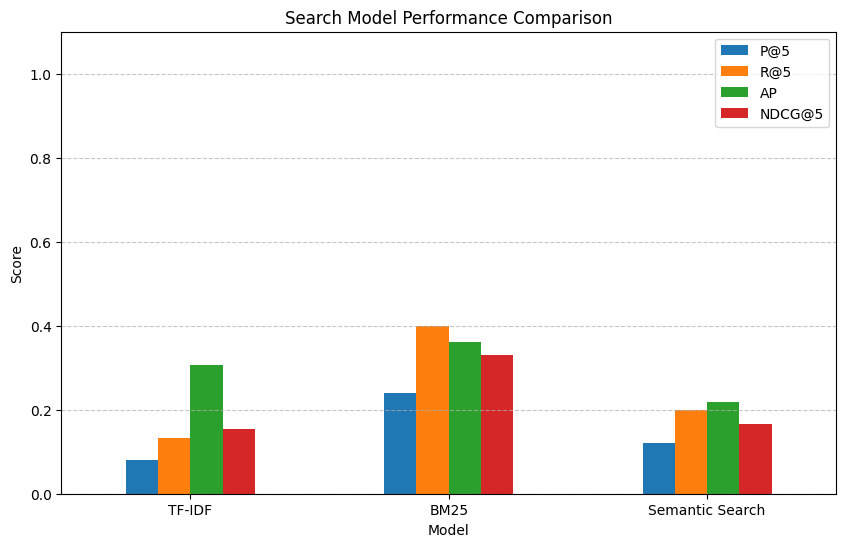

In [ ]:
# Para cada modelo e query:
# 1. Recuperar os top 10 documentos;
# 2. Calcular P@5, R@5, AP e NDCG@5;
# 3. Obter a média das métricas entre queries;
# 4. Mostrar tabela e gráfico de barras.
#
# A média de AP entre queries pode ser apresentada no relatório como MAP.
# -------------------------------------------------------------------------


import pandas as pd
import matplotlib.pyplot as plt

def run_comparison():
    models = {
    "TF-IDF": search_tfidf,
    "BM25": search_bm25,
    "Semantic Search": search_semantic
    }
    metrics = ["P@5", "R@5", "AP", "NDCG@5"]
    results_data = []

    for model_name, search_fn in models.items():
        all_scores = {m: [] for m in metrics}

        for query, relevant_ids in test_queries.items():
            results = search_fn(query, top_k=10)
            retrieved_ids = results['review_id'].tolist()

            all_scores["P@5"].append(precision_at_k(retrieved_ids, relevant_ids, k=5))
            all_scores["R@5"].append(recall_at_k(retrieved_ids, relevant_ids, k=5))
            all_scores["AP"].append(average_precision(retrieved_ids, relevant_ids))
            all_scores["NDCG@5"].append(ndcg_at_k(retrieved_ids, relevant_ids, k=5))

        # Average across queries
        model_summary = {m: np.mean(all_scores[m]) for m in metrics}
        model_summary["Model"] = model_name
        results_data.append(model_summary)

    return pd.DataFrame(results_data)

comparison_df = run_comparison()
display(comparison_df)

# Plotting
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Search Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Comparison Analysis

The evaluation results show differences between lexical and semantic retrieval approaches.

- TF-IDF performs well when query terms closely match document terms.
- BM25 improves lexical ranking by considering term frequency, inverse document frequency and document length normalization.
- Semantic Search captures contextual meaning and can retrieve conceptually related reviews even when exact keywords are absent.

According to the evaluation metrics used in this experiment — Precision@5, Recall@5, Average Precision and NDCG@5 — BM25 achieved the best overall performance.

This suggests that, for this dataset and these test queries, lexical matching was particularly effective because the queries used medical terms that also appeared directly in the review texts. However, Semantic Search remains useful for more natural language queries where users may not use the exact same words as the documents.

Because the relevance judgments were manually created for a small set of queries, these results should be interpreted as an exploratory comparison rather than a definitive benchmark.

## Learning to Rank (L2R)

### What is Learning to Rank?

Learning to Rank (L2R) is a supervised machine learning technique where a model learns how to sort documents in the most relevant order.

Classical models like BM25 only look at text-based relevance. However, in this project, ranking can also benefit from structured warehouse information such as user rating, effectiveness score and side-effect information.

We use a LambdaMART ranker through LightGBM to combine multiple signals:

1. Textual retrieval signals: BM25 score and Semantic Search score.
2. Structured warehouse signals: user rating and effectiveness-related information.

### Implementation Steps

1. Feature engineering: retrieve candidate documents and combine retrieval scores with warehouse attributes.
2. Training: use the manually defined relevance judgments from the test queries.
3. Inference: re-rank candidate documents for new queries.

This Learning-to-Rank component is an exploratory optional experiment. Since the training data is based on a small set of manually judged queries, the model should not be interpreted as a fully validated supervised ranking system.

LightGBM

   ↓

LambdaMART

   ↓

Learning to Rank

In [ ]:
# If needed in Colab:
# !pip install -q lightgbm
 #Features usadas:
# - bm25: score lexical BM25;
# - semantic: score de similaridade semântica;
# - rating: atributo estruturado proveniente do warehouse.
#
# rel é o target supervisionado:
# - 1 se a review foi julgada relevante;
# - 0 caso contrário.
#
# Limitação importante:
# O número de queries julgadas é pequeno. Este bloco demonstra o conceito,
# mas não constitui uma validação robusta de um modelo supervisionado.
# -----------------------------------------------------------------------

In [ ]:
import lightgbm as lgb
from lightgbm import LGBMRanker

# Fluxo em duas fases:
# 1. Recall phase: obter candidatos através de BM25 e Semantic Search;
# 2. Ranking phase: prever um novo score com o modelo treinado.
#
# A função devolve os documentos mais bem classificados após re-ranking.

def prepare_l2r_data(queries_dict):
    """
    Creates a feature-rich training set by joining search scores with the Warehouse.
    """
    rows = []

    for qid, (query, relevant_ids) in enumerate(queries_dict.items()):
        # 1. Get Top 20 from BM25 and Semantic to use as candidates
        bm25_res = search_bm25(query, top_k=20)
        semantic_res = search_semantic(query, top_k=20)

        # Combine all candidates
        candidate_ids = set(bm25_res['review_id']).union(set(semantic_res['review_id']))

        for rid in candidate_ids:
            # Features from Search Scores
            bm25_score = bm25_res[bm25_res['review_id'] == rid]['score'].iloc[0] if rid in bm25_res['review_id'].values else 0
            semantic_score = semantic_res[semantic_res['review_id'] == rid]['score'].iloc[0] if rid in semantic_res['review_id'].values else 0

            # Features from Data Warehouse (Fact Table)
            fact_row = fact_table[fact_table['review_id'] == rid].iloc[0]
            rating = fact_row['rating']

            # Target: 1 if in relevant_ids, else 0
            relevance = 1 if rid in relevant_ids else 0

            rows.append({
                'qid': qid,
                'review_id': rid,
                'bm25': bm25_score,
                'semantic': semantic_score,
                'rating': rating,
                'rel': relevance
            })

    return pd.DataFrame(rows)

# Prepare the training set
l2r_train_df = prepare_l2r_data(test_queries)

# Train the LGBMRanker
feature_cols = ['bm25', 'semantic', 'rating']
X = l2r_train_df[feature_cols]
y = l2r_train_df['rel']
groups = l2r_train_df.groupby('qid').size().to_numpy()

ranker = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=50,
    learning_rate=0.1
)

ranker.fit(X, y, group=groups)
print("L2R Model trained successfully using Warehouse features!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001656 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80
[LightGBM] [Info] Number of data points in the train set: 181, number of used features: 3
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [ ]:
def search_l2r(query, top_k=5):
    """
    Combined Search: Retrieves candidates and Re-ranks them using ML.
    """
    # 1. Retrieve candidates (Recall Phase)
    bm25_res = search_bm25(query, top_k=20)
    semantic_res = search_semantic(query, top_k=20)
    candidate_ids = list(set(bm25_res['review_id']).union(set(semantic_res['review_id'])))

    # 2. Build feature matrix for candidates
    features = []
    for rid in candidate_ids:
        b_score = bm25_res[bm25_res['review_id'] == rid]['score'].iloc[0] if rid in bm25_res['review_id'].values else 0
        s_score = semantic_res[semantic_res['review_id'] == rid]['score'].iloc[0] if rid in semantic_res['review_id'].values else 0
        rating = fact_table[fact_table['review_id'] == rid]['rating'].iloc[0]

        features.append([b_score, s_score, rating])

    # 3. Predict new ranks
    pred_scores = ranker.predict(np.array(features))

    # 4. Sort and return
    results = pd.DataFrame({
        'review_id': candidate_ids,
        'l2r_score': pred_scores
    }).sort_values('l2r_score', ascending=False).head(top_k)

    # Add original data for display
    return results.merge(df_reviews[['review_id', 'urlDrugName', 'condition', 'rating']], on='review_id')

print("Testing L2R Re-ranking for 'depression':")
display(search_l2r("depression", top_k=5))

Testing L2R Re-ranking for 'depression':


,review_id,l2r_score,urlDrugName,condition,rating
0,1595,-1.495702,lexapro,depression,2
1,537,-1.495702,singulair,allergies,2
2,335,-1.495702,remeron,depression,2
3,1530,-1.568519,serzone,depression,3
4,13,-2.049286,sarafem,depression,8


In [ ]:
query = "medicine for anxiety with low side effects"

print("SEMANTIC SEARCH RESULTS")
display(search_semantic(query, top_k=5))

SEMANTIC SEARCH RESULTS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
2771,2772,klonopin,Anxiety,Highly Effective,Moderate Side Effects,6,0.676549
2910,2911,alprazolam,"anxiety, panic attck, nervousness",Considerably Effective,Mild Side Effects,8,0.674724
518,519,alprazolam,"anxiety, panic attck, nervousness",Considerably Effective,Mild Side Effects,8,0.674724
2872,2873,alprazolam,Anxiety,Considerably Effective,Mild Side Effects,8,0.674271
561,562,risperdal,Anxiety,Considerably Effective,Moderate Side Effects,8,0.671735


In [ ]:
query = "effective treatment for depression"

print("=================================")
print("TF-IDF RESULTS")
print("=================================")

display(search_tfidf(query, top_k=5))

print("=================================")
print("BM25 RESULTS")
print("=================================")

display(search_bm25(query, top_k=5))

print("=================================")
print("SEMANTIC SEARCH RESULTS")
print("=================================")

display(search_semantic(query, top_k=5))

TF-IDF RESULTS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
258,259,zoloft,Depression,Considerably Effective,No Side Effects,9,0.383379
1581,1582,zoloft,depression/anxiety,Highly Effective,Moderate Side Effects,7,0.370785
2316,2317,effexor-xr,Depression,Moderately Effective,Mild Side Effects,7,0.364917
2404,2405,prozac,Depression,Considerably Effective,No Side Effects,9,0.332084
865,866,wellbutrin-xl,Depression,Highly Effective,Moderate Side Effects,9,0.328382


BM25 RESULTS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
2316,2317,effexor-xr,Depression,Moderately Effective,Mild Side Effects,7,7.381071
1581,1582,zoloft,depression/anxiety,Highly Effective,Moderate Side Effects,7,7.155991
865,866,wellbutrin-xl,Depression,Highly Effective,Moderate Side Effects,9,7.063944
2950,2951,effexor-xr,Depression,Marginally Effective,Severe Side Effects,3,6.818998
2404,2405,prozac,Depression,Considerably Effective,No Side Effects,9,6.687070


SEMANTIC SEARCH RESULTS


,review_id,drug_name_original,disease_name_original,effectiveness_label,side_effects_label,rating,score
2877,2878,wellbutrin,Depression,Highly Effective,No Side Effects,10,0.615387
545,546,zoloft,Depression,Considerably Effective,Mild Side Effects,5,0.613277
488,489,wellbutrin,Depression,Highly Effective,No Side Effects,10,0.598320
614,615,lexapro,Depression,Moderately Effective,Mild Side Effects,6,0.593423
2047,2048,lamictal,depresion anxiety obsessive behavior,Highly Effective,No Side Effects,9,0.591400


# Conclusions

This project successfully integrated heterogeneous healthcare datasets into a dimensional data warehouse. The warehouse combines drug information, disease/condition information, user reviews, effectiveness labels, side-effect labels, ratings and a time dimension.

The system then transformed warehouse data into searchable documents and implemented three retrieval approaches:

- TF-IDF
- BM25
- Semantic Search

TF-IDF and BM25 were used as classical information retrieval models, while Semantic Search was used as the advanced retrieval approach based on transformer embeddings.

The models were evaluated using the same test queries and manual relevance judgments. The evaluation used Precision@5, Recall@5, Average Precision and NDCG@5. In this experiment, BM25 achieved the best overall performance, suggesting that lexical matching was highly effective for the selected queries and dataset.

Semantic Search remains valuable because it can retrieve conceptually related documents even when users do not use the exact same terms found in the reviews.

A Learning-to-Rank model and a RAG-based conversational search prototype were also explored as optional extensions. However, due to the small number of manually judged queries and the medical nature of the domain, these components should be interpreted as preliminary demonstrations rather than fully validated systems.

Main limitations:
- the review dates are synthetic and should not be interpreted as real temporal information;
- the relevance judgments were manually created for a small set of queries;
- user reviews are subjective and may contain noisy or incomplete information;
- the system should not be used as medical advice.

## Bonus: Conversational Search (RAG)

### What is RAG (Retrieval-Augmented Generation)?
RAG is a technique that gives a Language Model (LLM) access to your private data (the Drug Reviews) to answer questions accurately without making things up ("hallucinations").

**The Workflow:**
1. **Retrieve:** Use our **L2R model** to find the most relevant drug reviews for a user question.
2. **Augment:** Put those reviews into a template (the "Context").
3. **Generate:** Use a Language Model to read the context and write a summary answer.

**Note:** This RAG component is an optional prototype. It is not intended to provide medical advice. The generated answer is based only on retrieved user reviews and may be incomplete or incorrect.


In [ ]:
# If needed in Colab:
# !pip install -q transformers torch

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# RAG = Retrieval-Augmented Generation.
#
# Fluxo:
# 1. search_l2r recupera reviews relevantes;
# 2. essas reviews tornam-se contexto;
# 3. FLAN-T5 gera uma resposta baseada no contexto recuperado.

# Load a small, efficient generator model
rag_model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(rag_model_name)
generator = AutoModelForSeq2SeqLM.from_pretrained(rag_model_name)

def generate_answer(query, context_docs):
    """
    Generates a natural language answer using retrieved reviews as context.
    """
    # 1. Combine retrieved reviews into a single text block
    context_text = "\n".join([
        f"Drug: {row['drug_name_original']}. Review: {row['benefits_review']}"
        for _, row in context_docs.iterrows()
    ])

    # 2. Build the RAG Prompt
    prompt = f"""
    Answer the question using ONLY the provided drug reviews context.

    Context:
    {context_text}

    Question: {query}

    Answer:
    """

    # 3. Generate tokens
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    outputs = generator.generate(**inputs, max_new_tokens=100)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

def conversational_search(query):
    """
    Full pipeline: L2R Retrieval -> RAG Generation
    """
    # Step 1: Retrieve best candidates using our smart L2R model
    # We need the full review text for context
    candidates = search_l2r(query, top_k=3)
    # Merge candidates with search_docs to get full review texts and original drug names
    context_docs = candidates.merge(search_docs, on='review_id', how='left')

    # Step 2: Generate answer
    answer = generate_answer(query, context_docs)

    print(f"\nQUESTION: {query}")
    print(f"AI ANSWER: {answer}")
    print("\n--- Sources Used ---")
    display(candidates[['urlDrugName', 'rating']])

#print("Testing RAG Conversational Search:")
#conversational_search("What are the benefits of drugs for depression?")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]